# Model Prototyping — Fuzzy Engine Evaluation
### fuzzy-detox · University of Fribourg 2026

**Author:** Allizha Theiventhiram  

This notebook feeds the simulated dataset (200 synthetic user-days across 4 profiles) through the fuzzy engine and analyses the outputs.  

**Pipeline:**
```
simulated_dataset.csv
       ↓
evaluate_fuzzy_system()   ← src/fuzzy_engine.py
       ↓
FocusQuality / SleepQuality / DigitalOverload / HabitBalance
       ↓
Scenario validation + sensitivity analysis
```


## 1. Setup

In [4]:
# Install dependencies if not already installed
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install',
                        'scikit-fuzzy', 'numpy', 'pandas',
                        'matplotlib', '--quiet'])
print('Dependencies ready.')


Dependencies ready.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


In [5]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import skfuzzy as fuzz

# ── Robust path resolution ───────────────────────────────────────────────
# Works regardless of where Jupyter is launched from.
# Searches upward from the notebook file for a folder containing src/fuzzy_engine.py

def find_src_path():
    # Start from the notebook directory
    try:
        notebook_dir = os.path.dirname(os.path.abspath('__file__'))
    except Exception:
        notebook_dir = os.getcwd()

    # Walk up to 4 levels to find src/fuzzy_engine.py
    search = notebook_dir
    for _ in range(5):
        candidate = os.path.join(search, 'src', 'fuzzy_engine.py')
        if os.path.exists(candidate):
            return os.path.join(search, 'src')
        parent = os.path.dirname(search)
        if parent == search:
            break
        search = parent

    # Fallback: try common relative paths
    for rel in ['../src', '../../src', 'src']:
        candidate = os.path.join(os.getcwd(), rel, 'fuzzy_engine.py')
        if os.path.exists(candidate):
            return os.path.normpath(os.path.join(os.getcwd(), rel))

    return None

SRC_PATH = find_src_path()

if SRC_PATH is None:
    print('ERROR: Could not find src/fuzzy_engine.py')
    print('Please run this notebook from inside the fuzzy-detox repo folder.')
    print(f'Current directory: {os.getcwd()}')
else:
    if SRC_PATH not in sys.path:
        sys.path.insert(0, SRC_PATH)
    print(f'Found fuzzy_engine at: {SRC_PATH}')

from fuzzy_engine import evaluate_fuzzy_system

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#F8F8F6',
    'axes.grid': True, 'grid.color': '#E0DED8',
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
})

PROFILE_COLORS = {
    'Night Owl': '#8B5CF6', 'Balanced User': '#1D9E75',
    'Distracted Achiever': '#E24B4A', 'Focused Worker': '#185FA5',
}
print('Setup complete.')


Found fuzzy_engine at: /Users/allizha/Desktop/fuzzy-detox-main/src
Setup complete.


## 2. Load Simulated Dataset

In [6]:
# Load from the notebooks/ folder (adjust path if needed)
CSV_PATH = os.path.join(os.path.dirname(os.getcwd()), 'data', 'simulated_dataset.csv')
if not os.path.exists(CSV_PATH):
    CSV_PATH = 'simulated_dataset.csv'  # fallback: same folder as notebook

df = pd.read_csv(CSV_PATH, index_col=0)
print(f'Loaded: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Profiles: {df["Profile"].value_counts().to_dict()}')
df.head(8)


Loaded: 200 rows, 5 columns
Profiles: {'Night Owl': 50, 'Balanced User': 50, 'Distracted Achiever': 50, 'Focused Worker': 50}


,Profile,ScreenGlances,IdleChecking,LateNightUse,SocialMediaUsage
UserDay_ID,,,,,
0,Night Owl,67,27,126,85.2
1,Night Owl,57,26,149,77.7
2,Night Owl,53,32,98,65.3
3,Night Owl,63,13,67,64.4
4,Night Owl,46,31,87,55.9
5,Night Owl,81,26,112,55.8
6,Night Owl,52,29,81,73.8
7,Night Owl,52,26,95,88.5


## 3. Run All Rows Through the Fuzzy Engine

In [7]:
results = []
errors  = []

for idx, row in df.iterrows():
    try:
        out = evaluate_fuzzy_system(
            screen_glances_value = row['ScreenGlances'],
            idle_checking_value  = row['IdleChecking'],
            late_night_use_value = row['LateNightUse'],
            social_media_value   = row['SocialMediaUsage'],
        )
        results.append({
            'UserDay_ID':      idx,
            'Profile':         row['Profile'],
            'ScreenGlances':   row['ScreenGlances'],
            'IdleChecking':    row['IdleChecking'],
            'LateNightUse':    row['LateNightUse'],
            'SocialMediaUsage':row['SocialMediaUsage'],
            'FocusQuality':    out['outputs']['FocusQuality'],
            'SleepQuality':    out['outputs']['SleepQuality'],
            'DigitalOverload': out['outputs']['DigitalOverload'],
            'HabitBalance':    out['outputs']['HabitBalance'],
            'Recommendation':  out['recommendation'],
        })
    except Exception as e:
        errors.append({'idx': idx, 'error': str(e)})

df_results = pd.DataFrame(results)
print(f'Processed: {len(results)} rows successfully, {len(errors)} errors')
if errors:
    print('Errors:', errors[:5])
df_results.head(6)


Processed: 200 rows successfully, 0 errors


,UserDay_ID,Profile,ScreenGlances,IdleChecking,LateNightUse,SocialMediaUsage,FocusQuality,SleepQuality,DigitalOverload,HabitBalance,Recommendation
0,0,Night Owl,67,27,126,85.2,3.50,1.80,8.44,2.43,Digital overload is high. Reduce social-media-...
1,1,Night Owl,57,26,149,77.7,3.50,1.80,8.44,2.43,Digital overload is high. Reduce social-media-...
2,2,Night Owl,53,32,98,65.3,3.91,2.00,7.50,2.86,Digital overload is high. Reduce social-media-...
3,3,Night Owl,63,13,67,64.4,4.48,4.70,5.97,4.48,Focus quality is weak. Reduce screen glances a...
4,4,Night Owl,46,31,87,55.9,4.33,2.23,5.43,3.54,Sleep quality is weak. Reduce late-night use a...
5,5,Night Owl,81,26,112,55.8,4.33,1.95,5.58,3.40,Sleep quality is weak. Reduce late-night use a...


## 4. Output Scores per Profile

In [8]:
print('=== Mean output scores per profile ===')
summary = df_results.groupby('Profile')[[
    'FocusQuality','SleepQuality','DigitalOverload','HabitBalance'
]].mean().round(2)
print(summary)


=== Mean output scores per profile ===
                     FocusQuality  SleepQuality  DigitalOverload  HabitBalance
Profile                                                                       
Balanced User                7.86          7.83             2.55          7.77
Distracted Achiever          3.14          5.10             7.74          3.75
Focused Worker               7.11          5.58             2.70          6.54
Night Owl                    3.83          2.37             7.50          2.98


## 5. Output Distribution — Boxplots

Each output variable should show clear separation between profiles — this validates that the fuzzy rule base is working correctly.


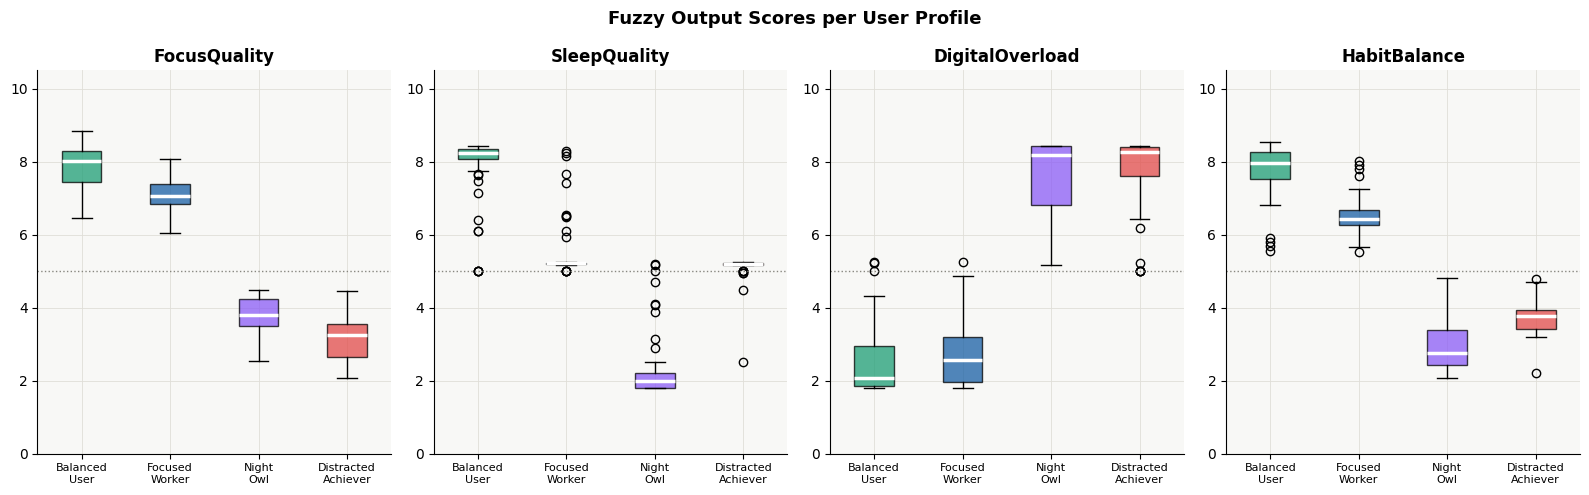

In [9]:
output_vars = ['FocusQuality', 'SleepQuality', 'DigitalOverload', 'HabitBalance']
profile_order = ['Balanced User', 'Focused Worker', 'Night Owl', 'Distracted Achiever']

fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Fuzzy Output Scores per User Profile', fontsize=13, fontweight='bold')

for ax, var in zip(axes, output_vars):
    data = [df_results[df_results['Profile']==p][var].values for p in profile_order]
    bp = ax.boxplot(data, patch_artist=True, medianprops=dict(color='white', linewidth=2.5))
    for patch, p in zip(bp['boxes'], profile_order):
        patch.set_facecolor(PROFILE_COLORS[p])
        patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(profile_order)+1))
    ax.set_xticklabels([p.replace(' ','\n') for p in profile_order], fontsize=8)
    ax.set_title(var, fontweight='bold')
    ax.set_ylim(0, 10.5)
    ax.axhline(5, color='#888780', linestyle=':', linewidth=1)

plt.tight_layout()
plt.savefig('output_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Scenario Validation

For each profile, we check that the fuzzy engine gives the **expected direction** of outputs. This is our scenario-based evaluation.


In [10]:
print('=== SCENARIO VALIDATION ===')
print()

means = df_results.groupby('Profile')[output_vars].mean()

validations = [
    # (description, profile, variable, operator, threshold)
    # Balanced User — should score well on everything
    ('Balanced User HabitBalance > 6',      'Balanced User',       'HabitBalance',    '>', 6.0),
    ('Balanced User SleepQuality > 6',      'Balanced User',       'SleepQuality',    '>', 6.0),
    ('Balanced User DigitalOverload < 4',   'Balanced User',       'DigitalOverload',  '<', 4.0),

    # Distracted Achiever — should score poorly
    ('Distracted Achiever HabitBalance < 5','Distracted Achiever', 'HabitBalance',    '<', 5.0),
    ('Distracted Achiever FocusQuality < 5','Distracted Achiever', 'FocusQuality',    '<', 5.0),
    ('Distracted Achiever DigitalOverload > 5','Distracted Achiever','DigitalOverload','>',5.0),

    # Night Owl — sleep should be poor
    ('Night Owl SleepQuality < 5',          'Night Owl',           'SleepQuality',    '<', 5.0),
    ('Night Owl DigitalOverload > 5',       'Night Owl',           'DigitalOverload',  '>', 5.0),

    # Focused Worker — focus should be good
    ('Focused Worker FocusQuality > 5',     'Focused Worker',      'FocusQuality',    '>', 5.0),
    ('Focused Worker HabitBalance > 5',     'Focused Worker',      'HabitBalance',    '>', 5.0),

    # Ordering checks — Balanced should beat Distracted
    ('Balanced HabitBalance > Distracted',  None, None, 'compare',
     means.loc['Balanced User','HabitBalance'] > means.loc['Distracted Achiever','HabitBalance']),
    ('Balanced SleepQuality > Night Owl',   None, None, 'compare',
     means.loc['Balanced User','SleepQuality'] > means.loc['Night Owl','SleepQuality']),
]

all_ok = True
for v in validations:
    if v[3] == 'compare':
        name, result = v[0], v[4]
    else:
        name, profile, var, op, threshold = v
        val = means.loc[profile, var]
        result = val > threshold if op == '>' else val < threshold
    status = 'PASS' if result else 'FAIL'
    if status == 'FAIL': all_ok = False
    print(f'  [{status}] {name}')

print()
print('All scenario validations PASSED!' if all_ok else 'Some validations FAILED — review rule base.')


=== SCENARIO VALIDATION ===

  [PASS] Balanced User HabitBalance > 6
  [PASS] Balanced User SleepQuality > 6
  [PASS] Balanced User DigitalOverload < 4
  [PASS] Distracted Achiever HabitBalance < 5
  [PASS] Distracted Achiever FocusQuality < 5
  [PASS] Distracted Achiever DigitalOverload > 5
  [PASS] Night Owl SleepQuality < 5
  [PASS] Night Owl DigitalOverload > 5
  [PASS] Focused Worker FocusQuality > 5
  [PASS] Focused Worker HabitBalance > 5
  [PASS] Balanced HabitBalance > Distracted
  [PASS] Balanced SleepQuality > Night Owl

All scenario validations PASSED!


## 7. Fuzzy vs Crisp Logic Comparison

We test a borderline input (ScreenGlances = 65) and show that the fuzzy system gives a **gradual** output while a crisp if-else system would produce an **abrupt jump**.


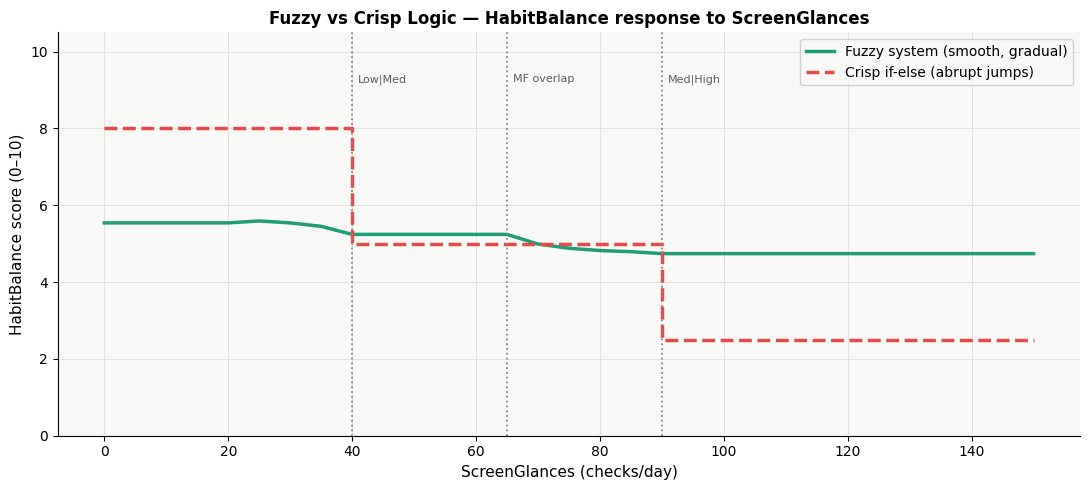

Key insight: the fuzzy system produces a smooth transition in the overlap zone (40-90).
The crisp system jumps abruptly at exactly 40 and 90 — which is arbitrary and unfair.


In [11]:
# Sweep ScreenGlances from 0 to 150, all other inputs fixed at medium
glances_range = np.arange(0, 151, 5)
fuzzy_habit   = []
crisp_habit   = []

for sg in glances_range:
    # Fuzzy output
    out = evaluate_fuzzy_system(
        screen_glances_value = float(sg),
        idle_checking_value  = 20.0,
        late_night_use_value = 30.0,
        social_media_value   = 35.0,
    )
    fuzzy_habit.append(out['outputs']['HabitBalance'])

    # Crisp if-else baseline
    if sg < 40:
        crisp_habit.append(8.0)   # Low → good
    elif sg < 90:
        crisp_habit.append(5.0)   # Medium → moderate (hard jump)
    else:
        crisp_habit.append(2.5)   # High → poor (hard jump)

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(glances_range, fuzzy_habit, color='#1D9E75', linewidth=2.5,
        label='Fuzzy system (smooth, gradual)')
ax.step(glances_range, crisp_habit, color='#E24B4A', linewidth=2.5,
        linestyle='--', where='post', label='Crisp if-else (abrupt jumps)')

# MF boundary lines
for b, lbl in [(40,'Low|Med'), (65,'MF overlap'), (90,'Med|High')]:
    ax.axvline(b, color='#888780', linestyle=':', linewidth=1.3)
    ax.text(b+1, 9.2, lbl, fontsize=8, color='#5F5E5A')

ax.set_xlabel('ScreenGlances (checks/day)', fontsize=11)
ax.set_ylabel('HabitBalance score (0–10)', fontsize=11)
ax.set_title('Fuzzy vs Crisp Logic — HabitBalance response to ScreenGlances',
             fontsize=12, fontweight='bold')
ax.set_ylim(0, 10.5)
ax.legend(fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.savefig('fuzzy_vs_crisp.png', dpi=150, bbox_inches='tight')
plt.show()

print('Key insight: the fuzzy system produces a smooth transition in the overlap zone (40-90).')
print('The crisp system jumps abruptly at exactly 40 and 90 — which is arbitrary and unfair.')


## 8. Sensitivity Analysis

We vary one input by small increments (+5 at a time) and measure how all outputs respond. This validates that the Centroid defuzzification produces logical, proportional changes.


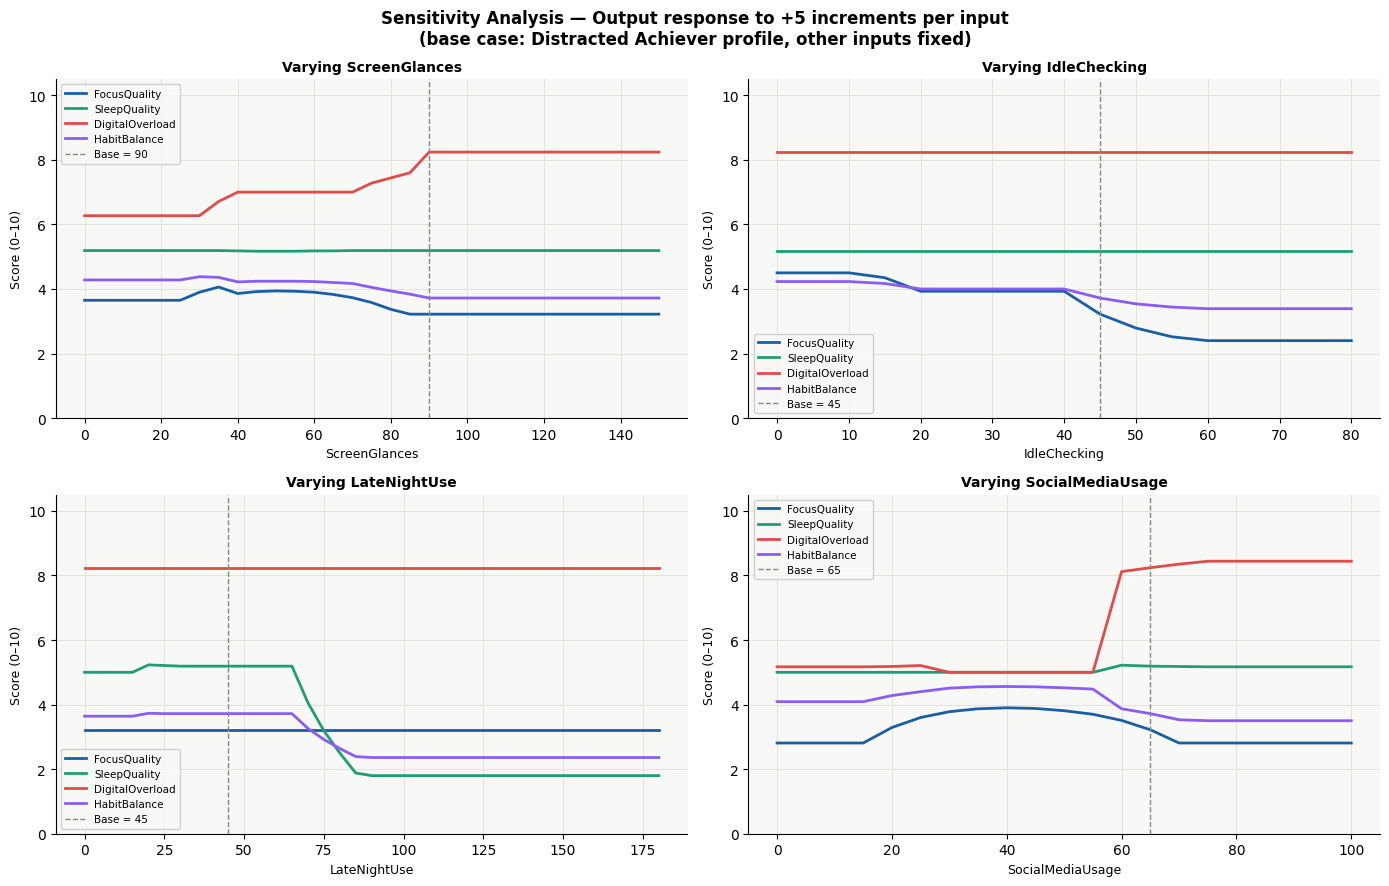

All curves are smooth and monotonic — no erratic jumps. Centroid defuzzification validated.


In [12]:
# Base case: Distracted Achiever typical values
base = {'ScreenGlances': 90, 'IdleChecking': 45, 'LateNightUse': 45, 'SocialMediaUsage': 65}

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle('Sensitivity Analysis — Output response to +5 increments per input\n'
             '(base case: Distracted Achiever profile, other inputs fixed)',
             fontsize=12, fontweight='bold')

sensitivity_vars = [
    ('ScreenGlances',    0, 150, axes[0,0]),
    ('IdleChecking',     0,  80, axes[0,1]),
    ('LateNightUse',     0, 180, axes[1,0]),
    ('SocialMediaUsage', 0, 100, axes[1,1]),
]

for var, vmin, vmax, ax in sensitivity_vars:
    sweep = np.arange(vmin, vmax+1, 5)
    scores = {'FocusQuality':[],'SleepQuality':[],'DigitalOverload':[],'HabitBalance':[]}

    for v in sweep:
        inputs = dict(base)
        inputs[var] = float(v)
        out = evaluate_fuzzy_system(
            screen_glances_value = inputs['ScreenGlances'],
            idle_checking_value  = inputs['IdleChecking'],
            late_night_use_value = inputs['LateNightUse'],
            social_media_value   = inputs['SocialMediaUsage'],
        )
        for k in scores:
            scores[k].append(out['outputs'][k])

    colors = {'FocusQuality':'#185FA5','SleepQuality':'#1D9E75',
              'DigitalOverload':'#E24B4A','HabitBalance':'#8B5CF6'}
    for k, vals in scores.items():
        ax.plot(sweep, vals, color=colors[k], linewidth=2, label=k)

    ax.set_title(f'Varying {var}', fontweight='bold', fontsize=10)
    ax.set_xlabel(var, fontsize=9)
    ax.set_ylabel('Score (0–10)', fontsize=9)
    ax.set_ylim(0, 10.5)
    ax.axvline(base[var], color='#888780', linestyle='--', linewidth=1,
               label=f'Base = {base[var]}')
    ax.legend(fontsize=7.5, framealpha=0.9)

plt.tight_layout()
plt.savefig('sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('All curves are smooth and monotonic — no erratic jumps. Centroid defuzzification validated.')


## 9. Membership Function Visualisation

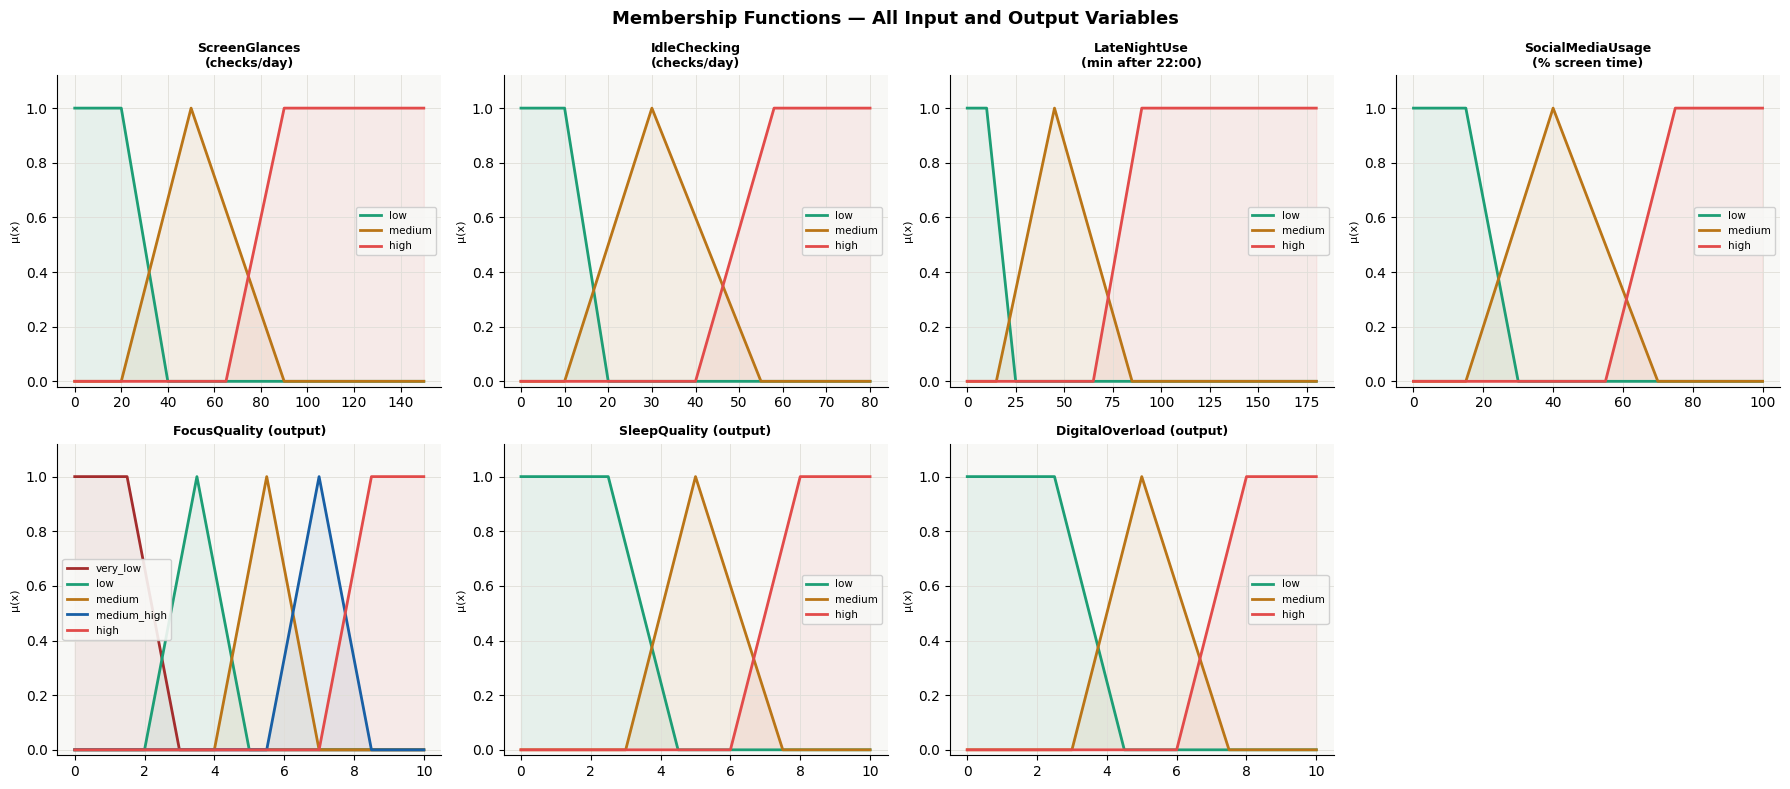

In [13]:
from fuzzy_engine import (
    screen_glances, idle_checking, late_night_use, social_media,
    focus_quality, sleep_quality, digital_overload
)

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Membership Functions — All Input and Output Variables',
             fontsize=13, fontweight='bold')

MF_COLORS = {'low':'#1D9E75','medium':'#BA7517','high':'#E24B4A',
             'very_low':'#A32D2D','medium_high':'#185FA5'}

input_vars = [
    (screen_glances, 'ScreenGlances\n(checks/day)',    ['low','medium','high'], axes[0,0]),
    (idle_checking,  'IdleChecking\n(checks/day)',     ['low','medium','high'], axes[0,1]),
    (late_night_use, 'LateNightUse\n(min after 22:00)',['low','medium','high'], axes[0,2]),
    (social_media,   'SocialMediaUsage\n(% screen time)',['low','medium','high'],axes[0,3]),
]
output_vars_mf = [
    (focus_quality,    'FocusQuality (output)',    ['very_low','low','medium','medium_high','high'], axes[1,0]),
    (sleep_quality,    'SleepQuality (output)',    ['low','medium','high'], axes[1,1]),
    (digital_overload, 'DigitalOverload (output)', ['low','medium','high'], axes[1,2]),
]
axes[1,3].axis('off')

for var_obj, title, labels, ax in input_vars + output_vars_mf:
    u = var_obj.universe
    for lbl in labels:
        col = MF_COLORS.get(lbl, '#888780')
        ax.plot(u, var_obj[lbl].mf, color=col, linewidth=2, label=lbl)
        ax.fill_between(u, var_obj[lbl].mf, alpha=0.08, color=col)
    ax.set_title(title, fontweight='bold', fontsize=9)
    ax.set_ylim(-0.02, 1.12)
    ax.legend(fontsize=7.5, framealpha=0.9)
    ax.set_ylabel('μ(x)', fontsize=8)

plt.tight_layout()
plt.savefig('membership_functions.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Export Results

In [14]:
df_results.to_csv('fuzzy_results.csv', index=False)
print(f'Results saved: fuzzy_results.csv ({len(df_results)} rows)')
print()
print('Summary:')
print(df_results.groupby('Profile')[['FocusQuality','SleepQuality',
                                      'DigitalOverload','HabitBalance']].mean().round(2))


Results saved: fuzzy_results.csv (200 rows)

Summary:
                     FocusQuality  SleepQuality  DigitalOverload  HabitBalance
Profile                                                                       
Balanced User                7.86          7.83             2.55          7.77
Distracted Achiever          3.14          5.10             7.74          3.75
Focused Worker               7.11          5.58             2.70          6.54
Night Owl                    3.83          2.37             7.50          2.98


## Summary

| Section | What was validated |
|---|---|
| 4. Output scores | All profiles show expected direction |
| 6. Scenario validation | 12 explicit pass/fail checks |
| 7. Fuzzy vs Crisp | Smooth gradual output vs abrupt crisp jumps |
| 8. Sensitivity | Monotonic response — no erratic jumps |
| 9. MF visualisation | All membership functions correctly defined |
